# Predict income (<$50K vs >$50K) 

## Importing libraries

In [585]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import math

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score, recall_score

import shap

In [586]:
with open('census-bureau.columns', 'r') as f:
    columns = [line.strip() for line in f.readlines() if line.strip()]

df = pd.read_csv('census-bureau.data', header=None, names=columns)
df.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


## Preliminary data understanding 

In [587]:
df.shape

(199523, 42)

In [588]:
df.columns

Index(['age', 'class of worker', 'detailed industry recode',
       'detailed occupation recode', 'education', 'wage per hour',
       'enroll in edu inst last wk', 'marital stat', 'major industry code',
       'major occupation code', 'race', 'hispanic origin', 'sex',
       'member of a labor union', 'reason for unemployment',
       'full or part time employment stat', 'capital gains', 'capital losses',
       'dividends from stocks', 'tax filer stat',
       'region of previous residence', 'state of previous residence',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'migration code-change in msa', 'migration code-change in reg',
       'migration code-move within reg', 'live in this house 1 year ago',
       'migration prev res in sunbelt', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'ow

In [589]:
# analyzed statistical distribution of numerical features
df.describe()

,age,detailed industry recode,detailed occupation recode,wage per hour,capital gains,capital losses,dividends from stocks,weight,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,year
count,199523.000000,199523.000000,199523.000000,199523.000000,199523.00000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000
mean,34.494199,15.352320,11.306556,55.426908,434.71899,37.313788,197.529533,1740.380269,1.956180,0.175438,1.514833,23.174897,94.499672
std,22.310895,18.067129,14.454204,274.896454,4697.53128,271.896428,1984.163658,993.768156,2.365126,0.553694,0.851473,24.411488,0.500001
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,37.870000,0.000000,0.000000,0.000000,0.000000,94.000000
25%,15.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1061.615000,0.000000,0.000000,2.000000,0.000000,94.000000
50%,33.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1618.310000,1.000000,0.000000,2.000000,8.000000,94.000000
75%,50.000000,33.000000,26.000000,0.000000,0.00000,0.000000,0.000000,2188.610000,4.000000,0.000000,2.000000,52.000000,95.000000
max,90.000000,51.000000,46.000000,9999.000000,99999.00000,4608.000000,99999.000000,18656.300000,6.000000,2.000000,2.000000,52.000000,95.000000


In [590]:
# analyzed statistical distribution of categorical features
df.describe(include='object')  

,class of worker,education,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,...,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,fill inc questionnaire for veteran's admin,label
count,199523,199523,199523,199523,199523,199523,199523,198649,199523,199523,...,199523,199523,199523,199523,199523,199523,199523,199523,199523,199523
unique,9,17,3,7,24,15,5,9,2,3,...,10,3,4,5,43,43,43,5,3,2
top,Not in universe,High school graduate,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,...,?,Not in universe under 1 year old,?,Not in universe,United-States,United-States,United-States,Native- Born in the United States,Not in universe,- 50000.
freq,100245,48407,186943,86485,100684,100684,167365,171907,103984,180459,...,99696,101212,99696,144232,159163,160479,176989,176992,197539,187141


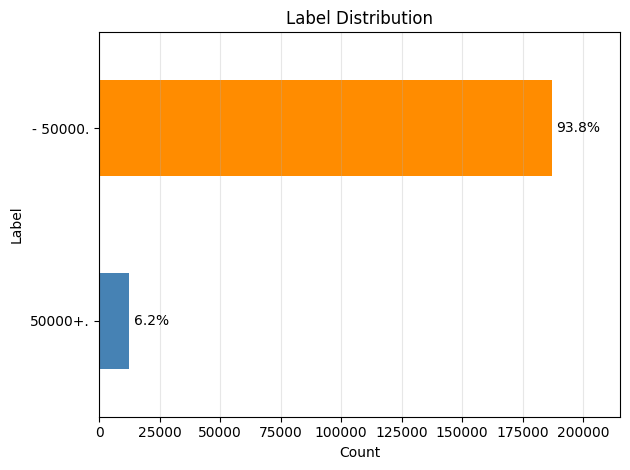

In [591]:
# class imbalance is significant :( 

counts = df['label'].value_counts().sort_values()
perc = (counts / counts.sum() * 100)

ax = counts.plot(
    kind='barh',
    title='Label Distribution',
    color=['steelblue', 'darkorange']
)

plt.xlabel('Count')
plt.ylabel('Label')
plt.grid(axis='x', alpha=0.3)
ax.set_xlim(0, counts.max() * 1.15)

for i, (v, p) in enumerate(zip(counts.values, perc.values)):
    ax.text(v + counts.max() * 0.01, i, f"{p:.1f}%", va='center', fontsize=10)

plt.tight_layout()

In [592]:
missing_counts = df.replace('?', np.nan).isnull().sum().sort_values(ascending=False)
missing_counts.head(10)

migration code-change in msa      99696
migration code-change in reg      99696
migration code-move within reg    99696
migration prev res in sunbelt     99696
country of birth father            6713
country of birth mother            6119
country of birth self              3393
hispanic origin                     874
state of previous residence         708
citizenship                           0
dtype: int64

In [593]:
columns_to_drop = [
    'year',  # Minimal variance (only 1994-1995)
    'fill inc questionnaire for veteran\'s admin',  # Administrative variable
    
    # Likely low value (too granular or redundant)
    'detailed industry recode',  # Use 'major industry code' instead
    'detailed occupation recode',  # Use 'major occupation code' instead
    'state of previous residence',  # Too sparse, use 'region of previous residence'
    'detailed household summary in household',  # Redundant with 'detailed household and family stat'
    
    # High missing values (~50% missing)
    'migration code-change in msa', 
    'migration code-change in reg',  
    'migration code-move within reg', 
    'migration prev res in sunbelt',  
    
    # Not relevant
    'country of birth father',  # not that relevant
    'country of birth mother',  # not that relevant
    'hispanic origin', # not that relevant
    # 'veterans benefits'  # Sparse, niche segment not generalizable
]

df = df.drop(columns=columns_to_drop)

In [594]:
print("Number of duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Number of duplicates: 3908


In [595]:
df.head()

,age,class of worker,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,sex,...,weight,live in this house 1 year ago,num persons worked for employer,family members under 18,country of birth self,citizenship,own business or self employed,veterans benefits,weeks worked in year,label
0,73,Not in universe,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,Female,...,1700.09,Not in universe under 1 year old,0,Not in universe,United-States,Native- Born in the United States,0,2,0,- 50000.
1,58,Self-employed-not incorporated,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,Male,...,1053.55,No,1,Not in universe,United-States,Native- Born in the United States,0,2,52,- 50000.
2,18,Not in universe,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,Female,...,991.95,Not in universe under 1 year old,0,Not in universe,Vietnam,Foreign born- Not a citizen of U S,0,2,0,- 50000.
3,9,Not in universe,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,Female,...,1758.14,Yes,0,Both parents present,United-States,Native- Born in the United States,0,0,0,- 50000.
4,10,Not in universe,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,Female,...,1069.16,Yes,0,Both parents present,United-States,Native- Born in the United States,0,0,0,- 50000.


### Extracting numerical and categorical values

In [596]:
unique_counts = df.nunique()

potential_categorical = unique_counts[unique_counts < 20].index.tolist()

potential_numerical = unique_counts[unique_counts >= 50].index.tolist()

gray_area = unique_counts[(unique_counts >= 20) & (unique_counts < 50)]
print("Need to manually check:\n", gray_area)

Need to manually check:
 major industry code                   24
detailed household and family stat    38
country of birth self                 43
dtype: int64


In [597]:
numerical_cols = [
    'age',
    'wage per hour',
    'capital gains',
    'capital losses',
    'dividends from stocks',
    'weeks worked in year',
    'num persons worked for employer'
]

categorical_cols = df.columns[~df.columns.isin(numerical_cols)].tolist()

## Exploratory Data Analysis

### Univariate Analysis

#### Distribution

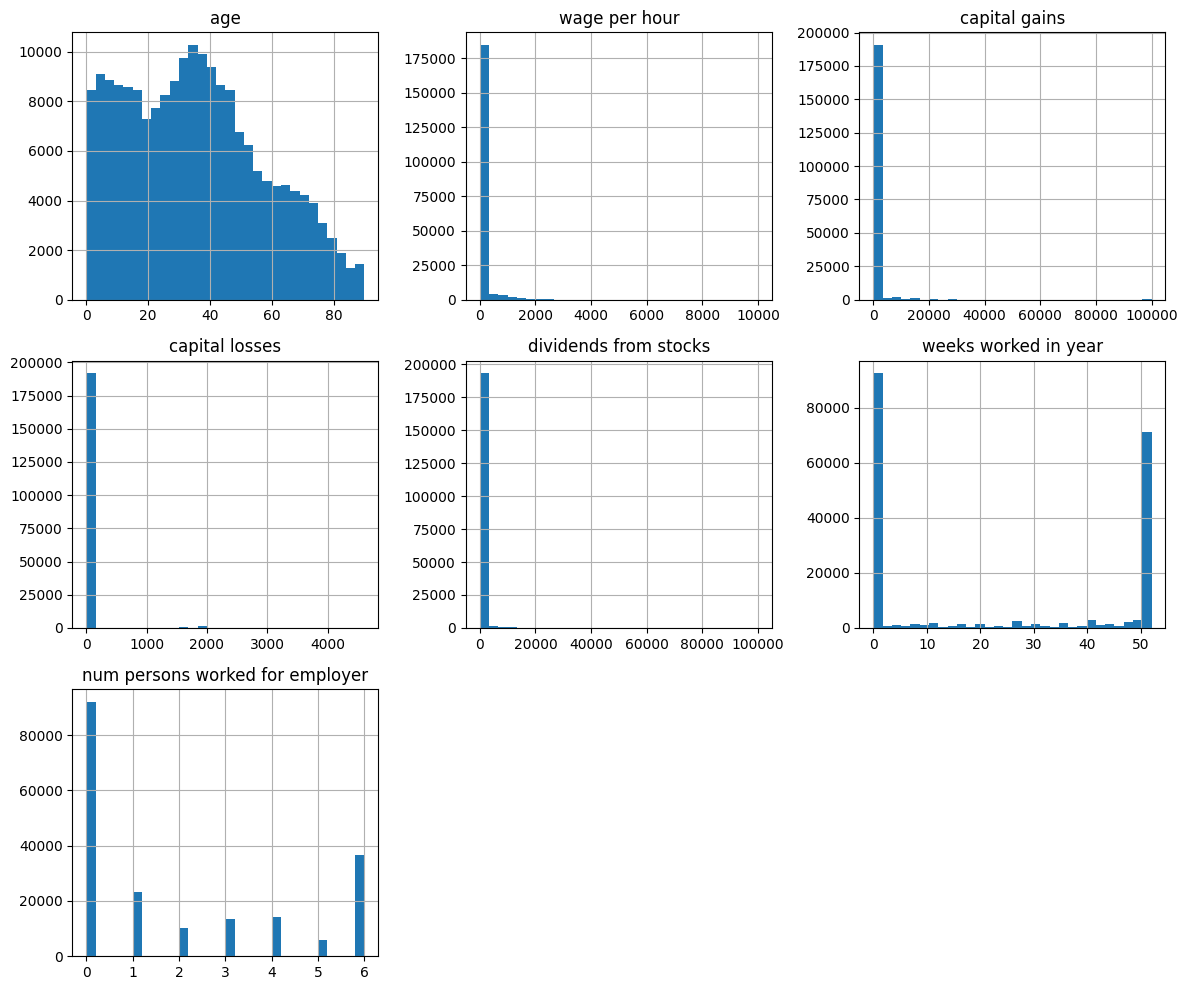

In [598]:
df[numerical_cols].hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()

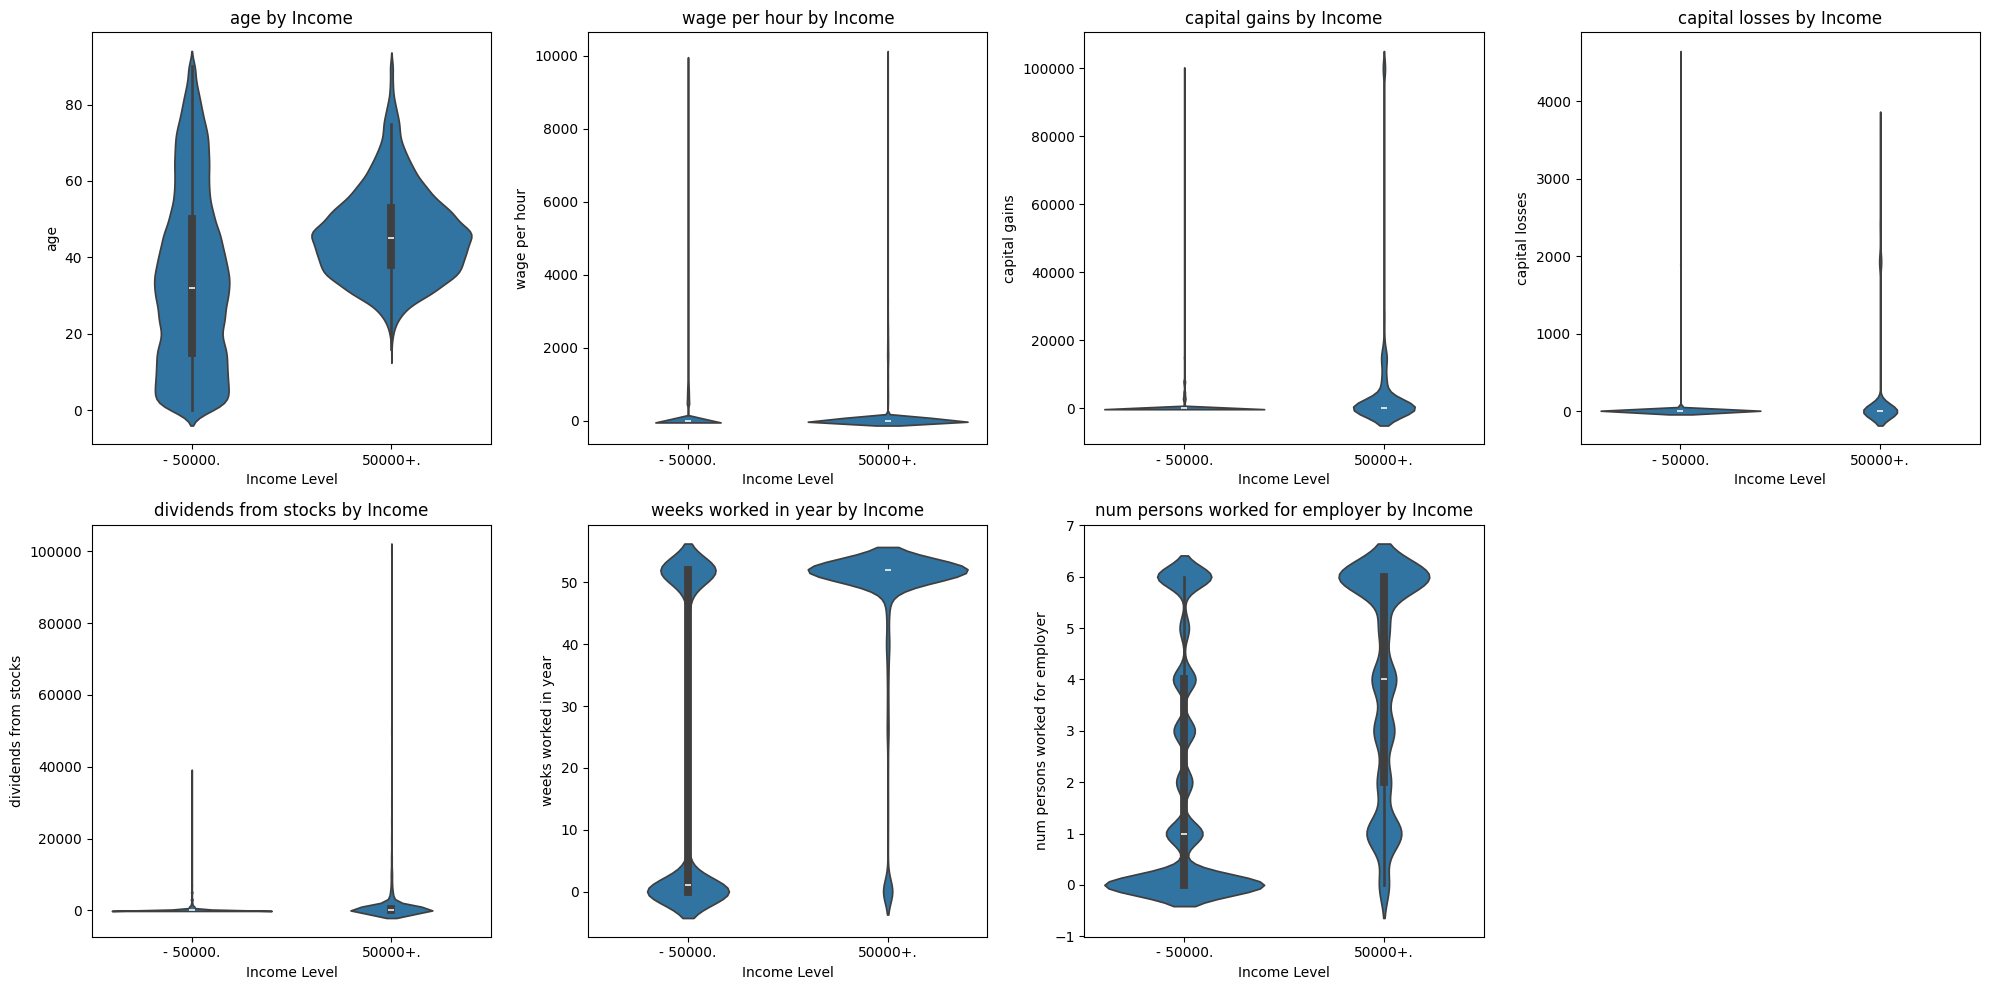

In [599]:
# Create grid of violin plots for all numerical features

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    sns.violinplot(x='label', y=col, data=df, ax=axes[idx])
    axes[idx].set_title(f'{col} by Income')
    axes[idx].set_xlabel('Income Level')

if len(numerical_cols) < 8:
    fig.delaxes(axes[-1])
    
plt.tight_layout()
plt.show()

#### Outliers

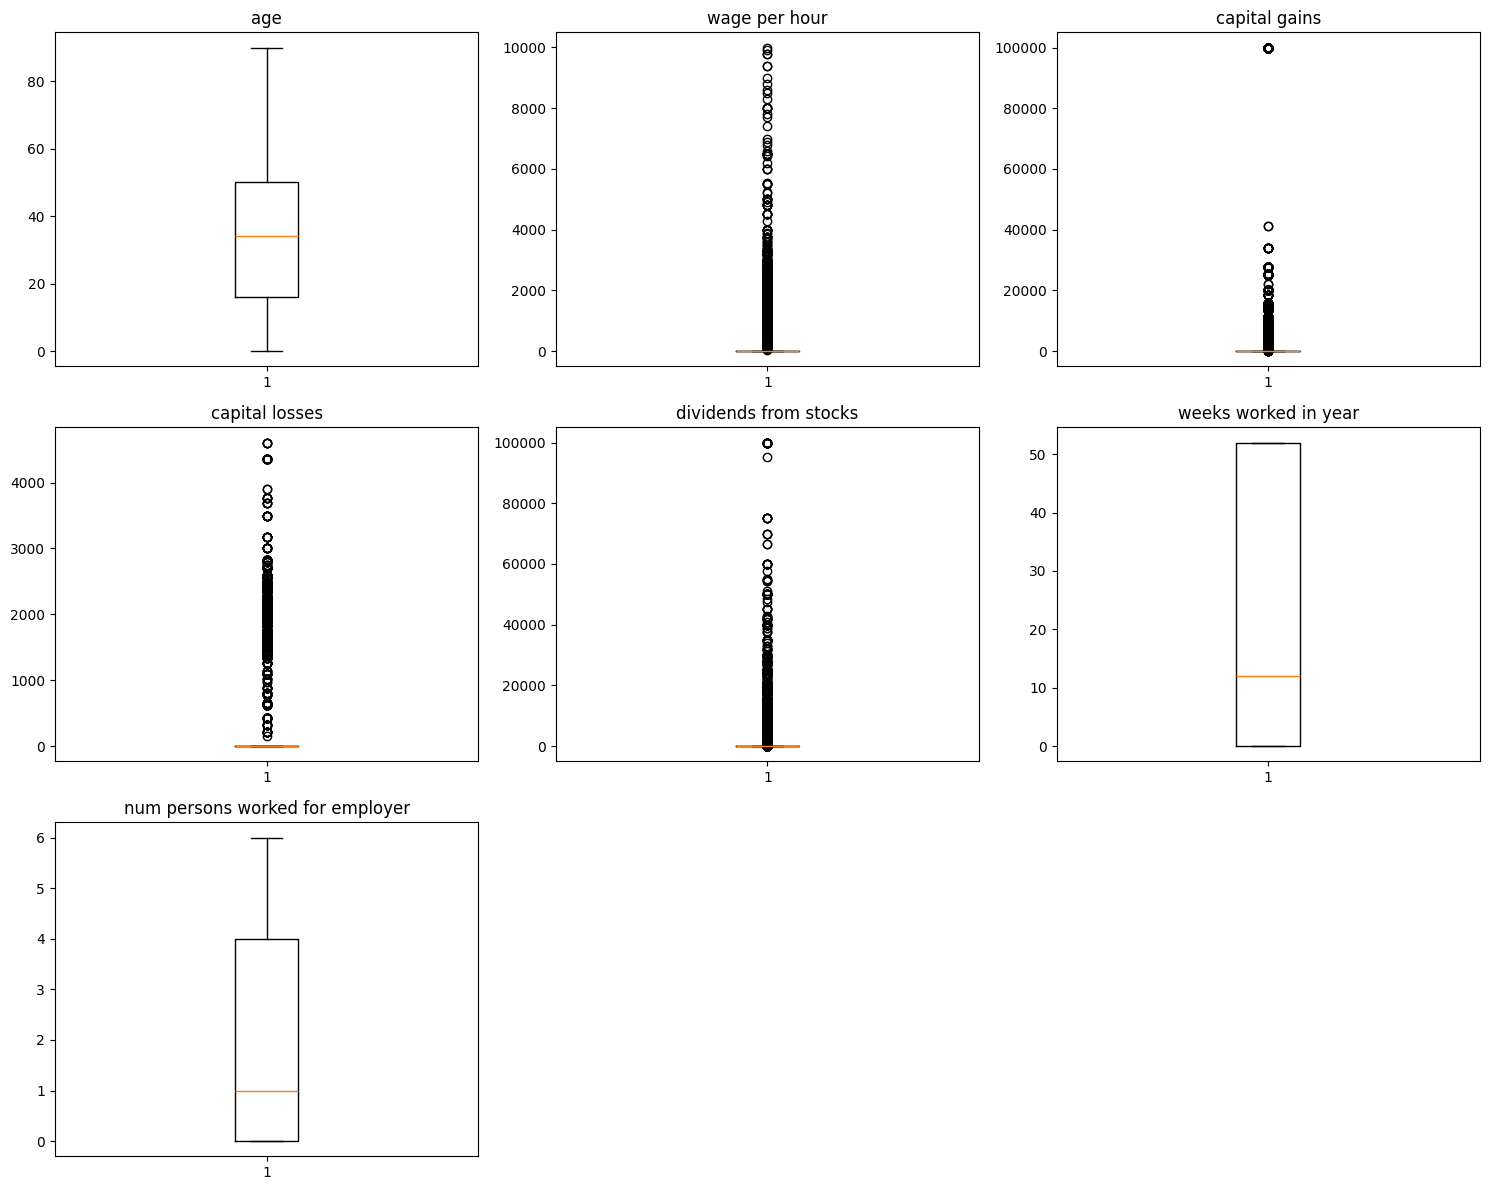

In [600]:
n = len(numerical_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [601]:
# binary features

# # i will likely drop wage_per_hour
#     wage_per_hour 

# #strong predictor
#     capital_gains 

# #strong predictor
#     capital_losses 

# #strong predictor
#     dividends_from_stocks

# # very strong predictor
#     works_full_year 

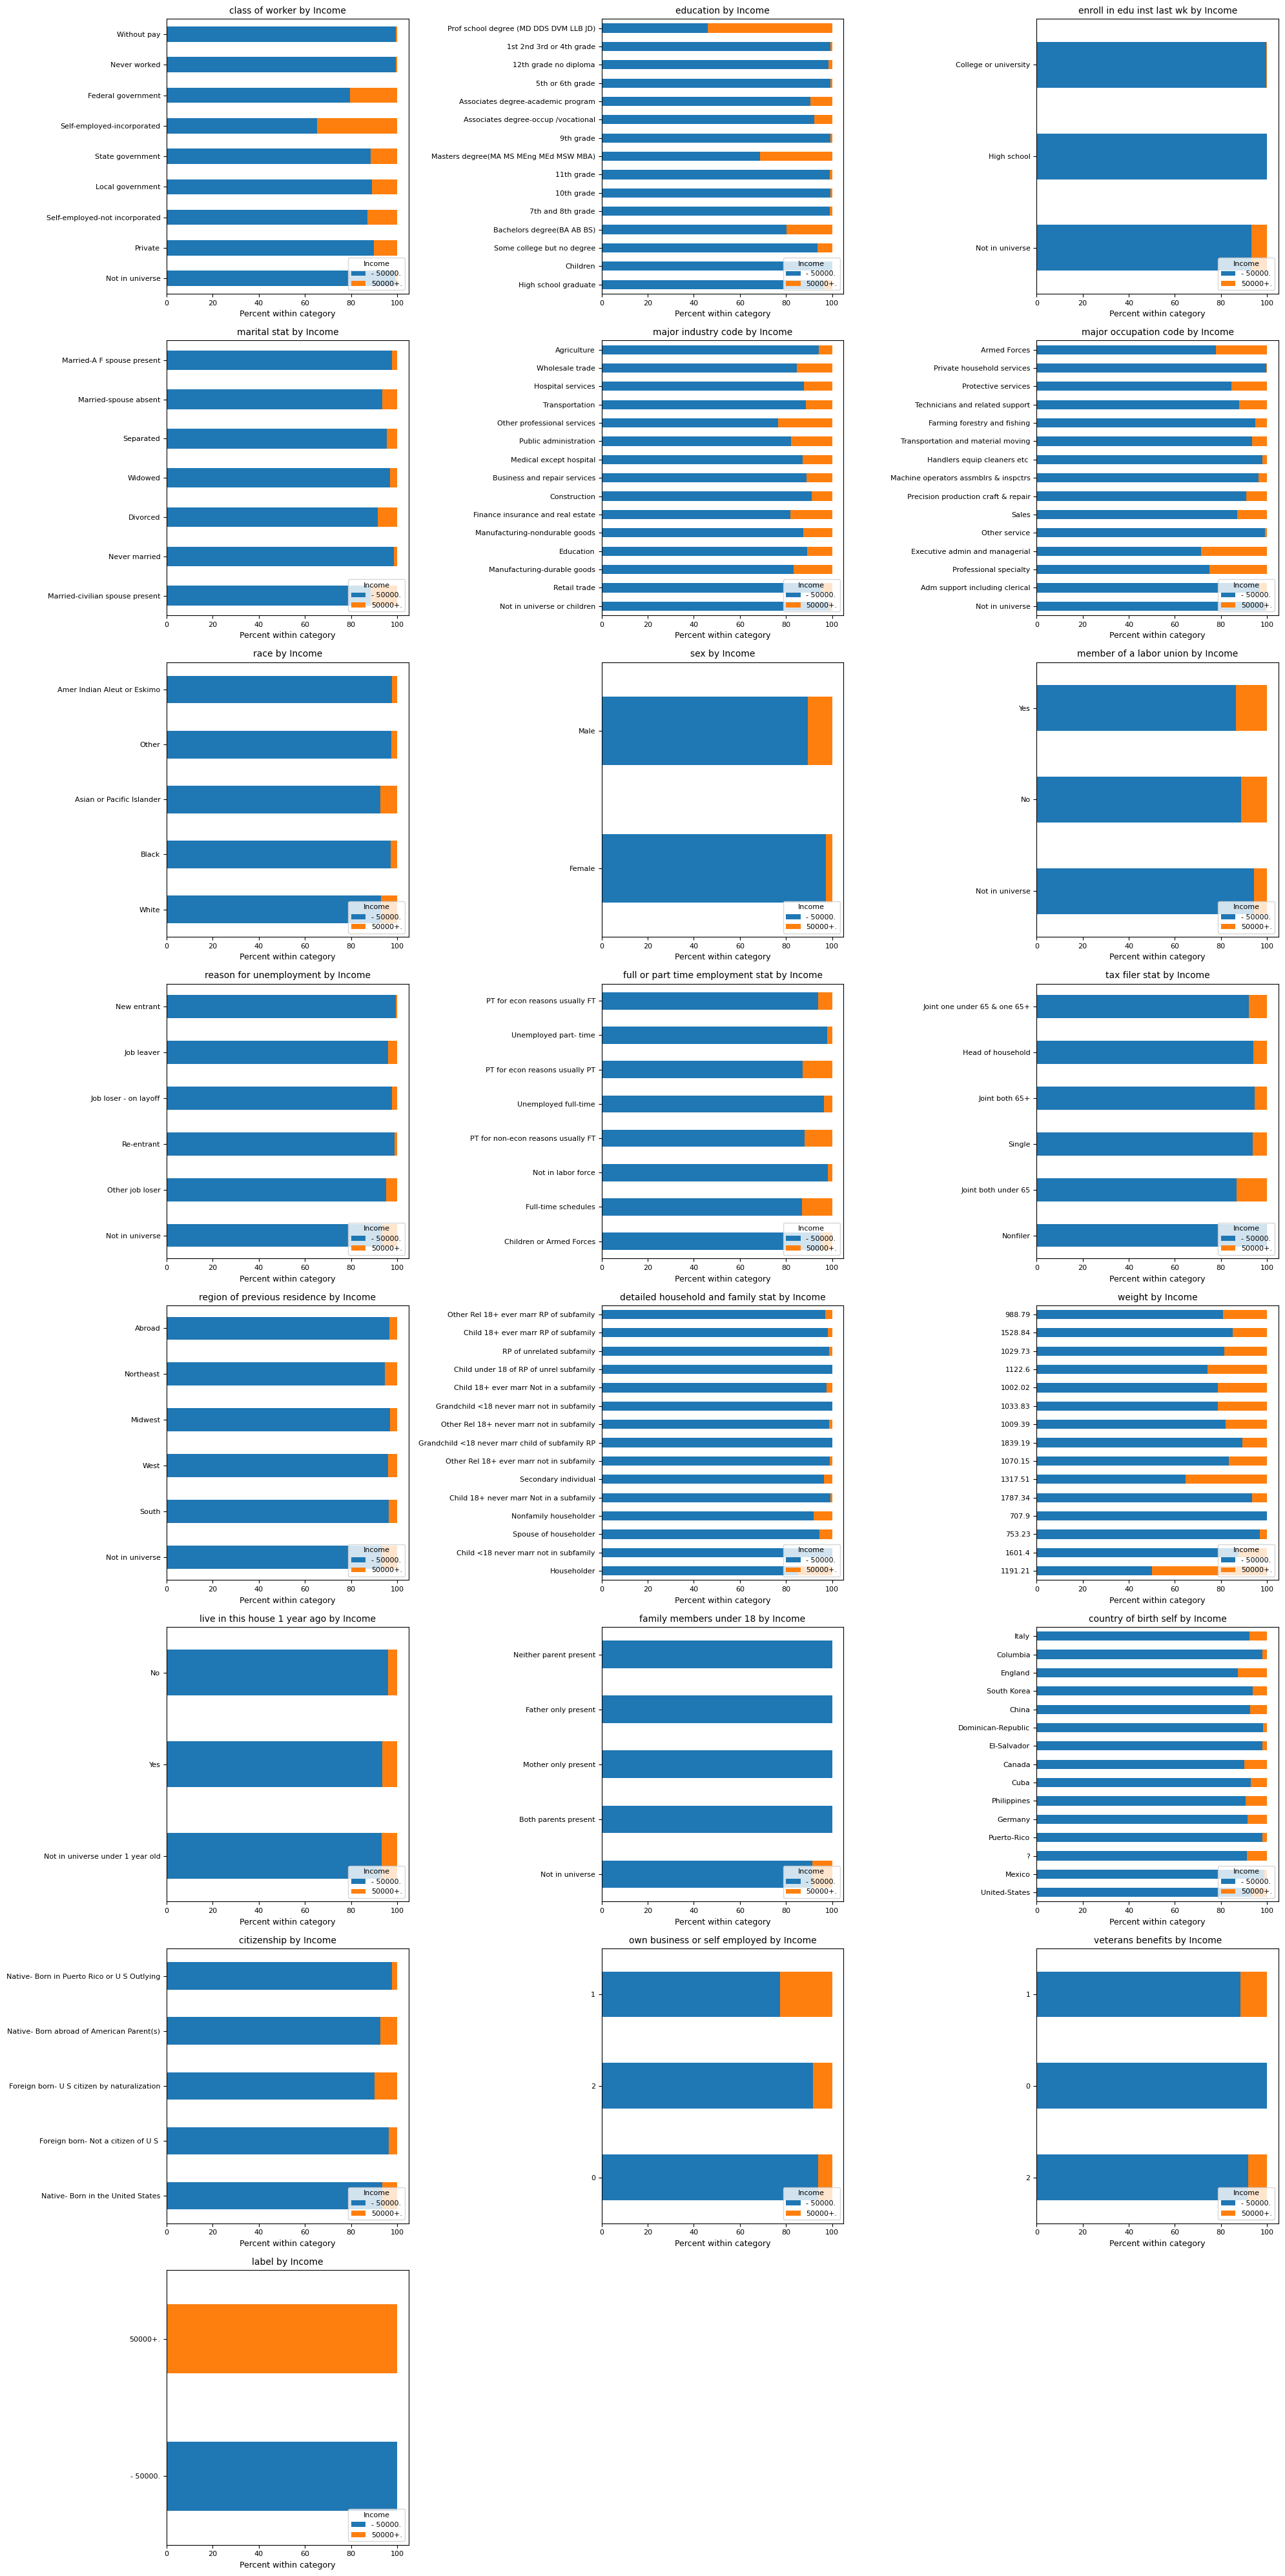

In [602]:
n_features = len(categorical_cols)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    top_cats = df[col].value_counts().head(15).index
    df_sub = df[df[col].isin(top_cats)].copy()
    ct = pd.crosstab(df_sub[col], df_sub['label'], normalize='index') * 100

    ct = ct.reindex(top_cats)

    ct.plot(kind='barh', stacked=True, ax=axes[idx])

    axes[idx].set_title(col + " by Income", fontsize=10)
    axes[idx].set_xlabel("Percent within category", fontsize=9)
    axes[idx].set_ylabel("")
    axes[idx].tick_params(labelsize=8)
    axes[idx].legend(title="Income", fontsize=8, title_fontsize=8, loc="lower right")

for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


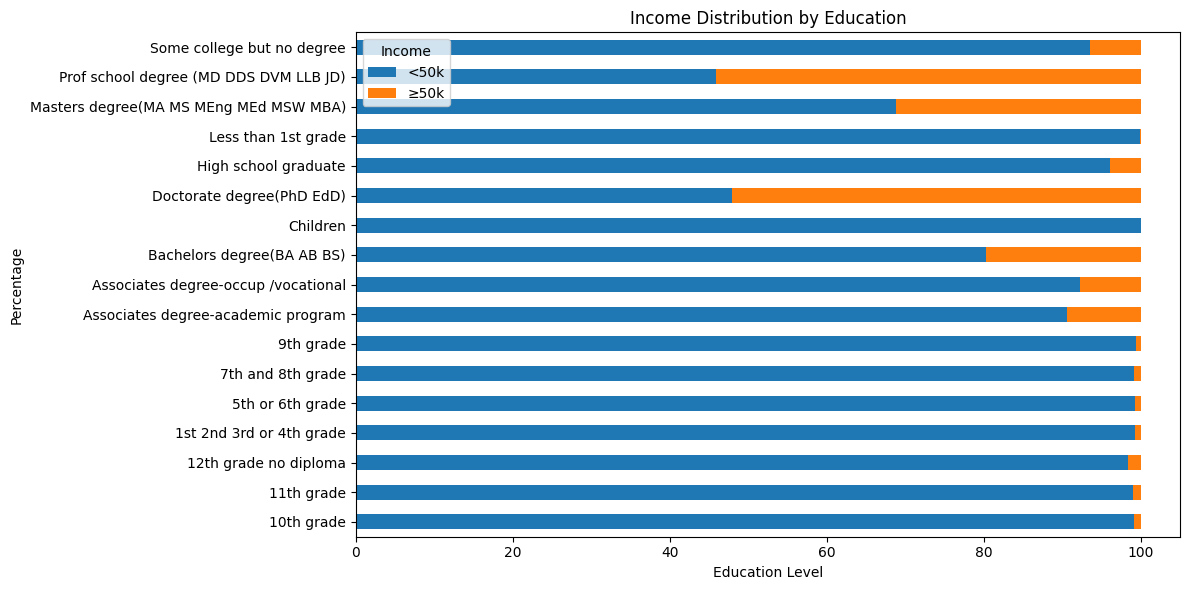

In [603]:
# Calculate percentage of >50k in each education level
edu_income = pd.crosstab(df['education'], df['label'], normalize='index') * 100

edu_income.plot(kind='barh', stacked=True, figsize=(12, 6))
plt.title('Income Distribution by Education')
plt.ylabel('Percentage')
plt.xlabel('Education Level')

plt.legend(title='Income', labels=['<50k', '≥50k'])
plt.tight_layout()
plt.show()

In [604]:
edu_pct = pd.crosstab(df['education'], df['label'], normalize='index') * 100
print(edu_pct['50000+.'].sort_values(ascending=False))

education
Prof school degree (MD DDS DVM LLB JD)    54.043503
Doctorate degree(PhD EdD)                 52.019002
Masters degree(MA MS MEng MEd MSW MBA)    31.162080
Bachelors degree(BA AB BS)                19.714976
Associates degree-academic program         9.443044
Associates degree-occup /vocational        7.708100
Some college but no degree                 6.426671
High school graduate                       3.885201
12th grade no diploma                      1.600000
11th grade                                 1.020259
7th and 8th grade                          0.902708
10th grade                                 0.823155
1st 2nd 3rd or 4th grade                   0.722624
5th or 6th grade                           0.671346
9th grade                                  0.614390
Less than 1st grade                        0.122549
Children                                   0.000000
Name: 50000+., dtype: float64


## Feature Engineering



In [605]:
# education - top predictor
# Marital status - married >> others
# major occupation code - some jobs pay more
# race - white >> others
# sex - male >> female

# maybe i drop
# major industry code
# member of a labor union
# enroll in edu

In [606]:
# creating new features 

def education_tier(edu):
    if edu in ['Prof school degree (MD DDS DVM LLB JD)', 'Doctorate degree(PhD EdD)']:
        return 'Advanced_Professional' 
    elif 'Masters' in edu:
        return 'Masters'  
    elif 'Bachelors' in edu:
        return 'Bachelors'  
    elif 'Associates' in edu or 'Some college' in edu:
        return 'Some_College'  
    elif 'High school' in edu:
        return 'High_School'  
    elif 'Children' in edu:
        return 'Child'  #
    else:
        return 'Less_than_HS'  

def marital_category(status):
    if 'Married' in status and 'spouse present' in status:
        return 'Married'
    elif 'Never married' in status:
        return 'Never_married'
    else:  
        return 'Previously_married'

def household_information(hh):
    if 'Householder' in hh:
        return 'Householder'
    elif 'Spouse' in hh:
        return 'Spouse'
    elif 'Child' in hh:
        return 'Child'
    else:
        return 'Other_Relative'

def occupation_tier(occ):
    if occ in ['Professional specialty', 'Executive admin and managerial']:
        return 'High_Skill'
    elif occ in ['Technicians and related support', 'Sales', 'Adm support including clerical']:
        return 'Mid_Skill'
    elif occ == 'Not in universe':
        return 'Not_Working'
    else:
        return 'Low_Skill'  

def industry_tier(industry): 
    if industry in ['Finance insurance and real estate', 'Mining', 
                    'Utilities and sanitary services', 'Communications', 
                    'Public administration']:
        return 'High_Pay'
    
    elif industry == 'Not in universe or children':
        return 'Not_Working'
    
    elif industry in ['Retail trade', 'Agriculture', 
                      'Personal services except private HH',
                      'Private household services', 'Entertainment', 
                      'Social services', 'Armed Forces',
                      'Forestry and fisheries']:
        return 'Low_Pay'
    
    else:
        return 'Mid_Pay'

def tax_category(tax):
    if 'Joint' in tax:
        return 'Joint_Filer'
    elif tax == 'Nonfiler':
        return 'Non_Filer'
    else:
        return 'Single_Filer' 

def worker_class_tier(cls):
    if cls == 'Private':
        return 'Private'
    elif 'government' in cls.lower():
        return 'Government'  
    elif 'Self-employed' in cls:
        return 'Self_Employed'
    elif cls in ['Never worked', 'Without pay']:
        return 'Never_Worked'
    else:
        return 'Not_Working'  

def employment_status(row):
    stat = row['full or part time employment stat']
    age = row['age']
    weeks = row['weeks worked in year']

    if stat == 'Full-time schedules':
        return 'Full_Time_Employed'

    elif stat == 'Children or Armed Forces':

        if age < 18 and weeks < 10:
            return 'Not_Working'
        
        elif age >= 18 and weeks >= 40:
            return 'Full_Time_Employed'
        
        elif age >= 18 and weeks > 0:
            return 'Part_Time_Employed'
        
        else:
            return 'Not_Working'

    elif 'PT for' in stat:
        return 'Part_Time_Employed'
    
    elif 'Unemployed' in stat:
        return 'Unemployed'
    
    elif stat == 'Not in labor force':
        return 'Not_In_Labor_Force'
    
    else:
        return 'Not_Working'

# converting into binary features + dropping original features

df['has_capital_gains'] = (df['capital gains'] > 0).astype(int)
df['has_capital_losses'] = (df['capital losses'] > 0).astype(int)
df['has_dividends'] = (df['dividends from stocks'] > 0).astype(int)

df['works_full_year'] = (df['weeks worked in year'] == 52).astype(int)

df.drop(columns=['capital gains', 'capital losses', 'dividends from stocks'], inplace=True)

In [607]:
df['education_tier'] = df['education'].apply(education_tier)
df['marital_category'] = df['marital stat'].apply(marital_category)
df['household_role'] = df['detailed household and family stat'].apply(household_information)
df['occupation_tier'] = df['major occupation code'].apply(occupation_tier)
df['industry_pay_level'] = df['major industry code'].apply(industry_tier)
df['tax_category'] = df['tax filer stat'].apply(tax_category)
df['worker_class_simple'] = df['class of worker'].apply(worker_class_tier)
df['employment_status'] = df.apply(employment_status, axis=1)

df.drop(columns=['education', 'marital stat', 'detailed household and family stat', 'major occupation code', 'major industry code', 'tax filer stat', 'class of worker', 'full or part time employment stat'], inplace=True)

In [608]:
features_to_drop = [
    'enroll in edu inst last wk',  # 95% "Not in universe"
    'member of a labor union',  # 95% "Not in universe"
    'reason for unemployment',  # 98% "Not in universe" (most people working)
    'region of previous residence',  # 95% "Not in universe"
    'live in this house 1 year ago',  # Mostly "Yes", low signal
    'veterans benefits',  # 99% not applicable
    'country of birth self',  # 90% United States, sparse elsewhere
    'citizenship',  # 95% native born, redundant with country
    'own business or self employed',  # Mostly 0, low variance
    'family members under 18'  # Mostly "Not in universe"
]

df = df.drop(features_to_drop, axis=1)

In [609]:
df.shape

(195615, 20)

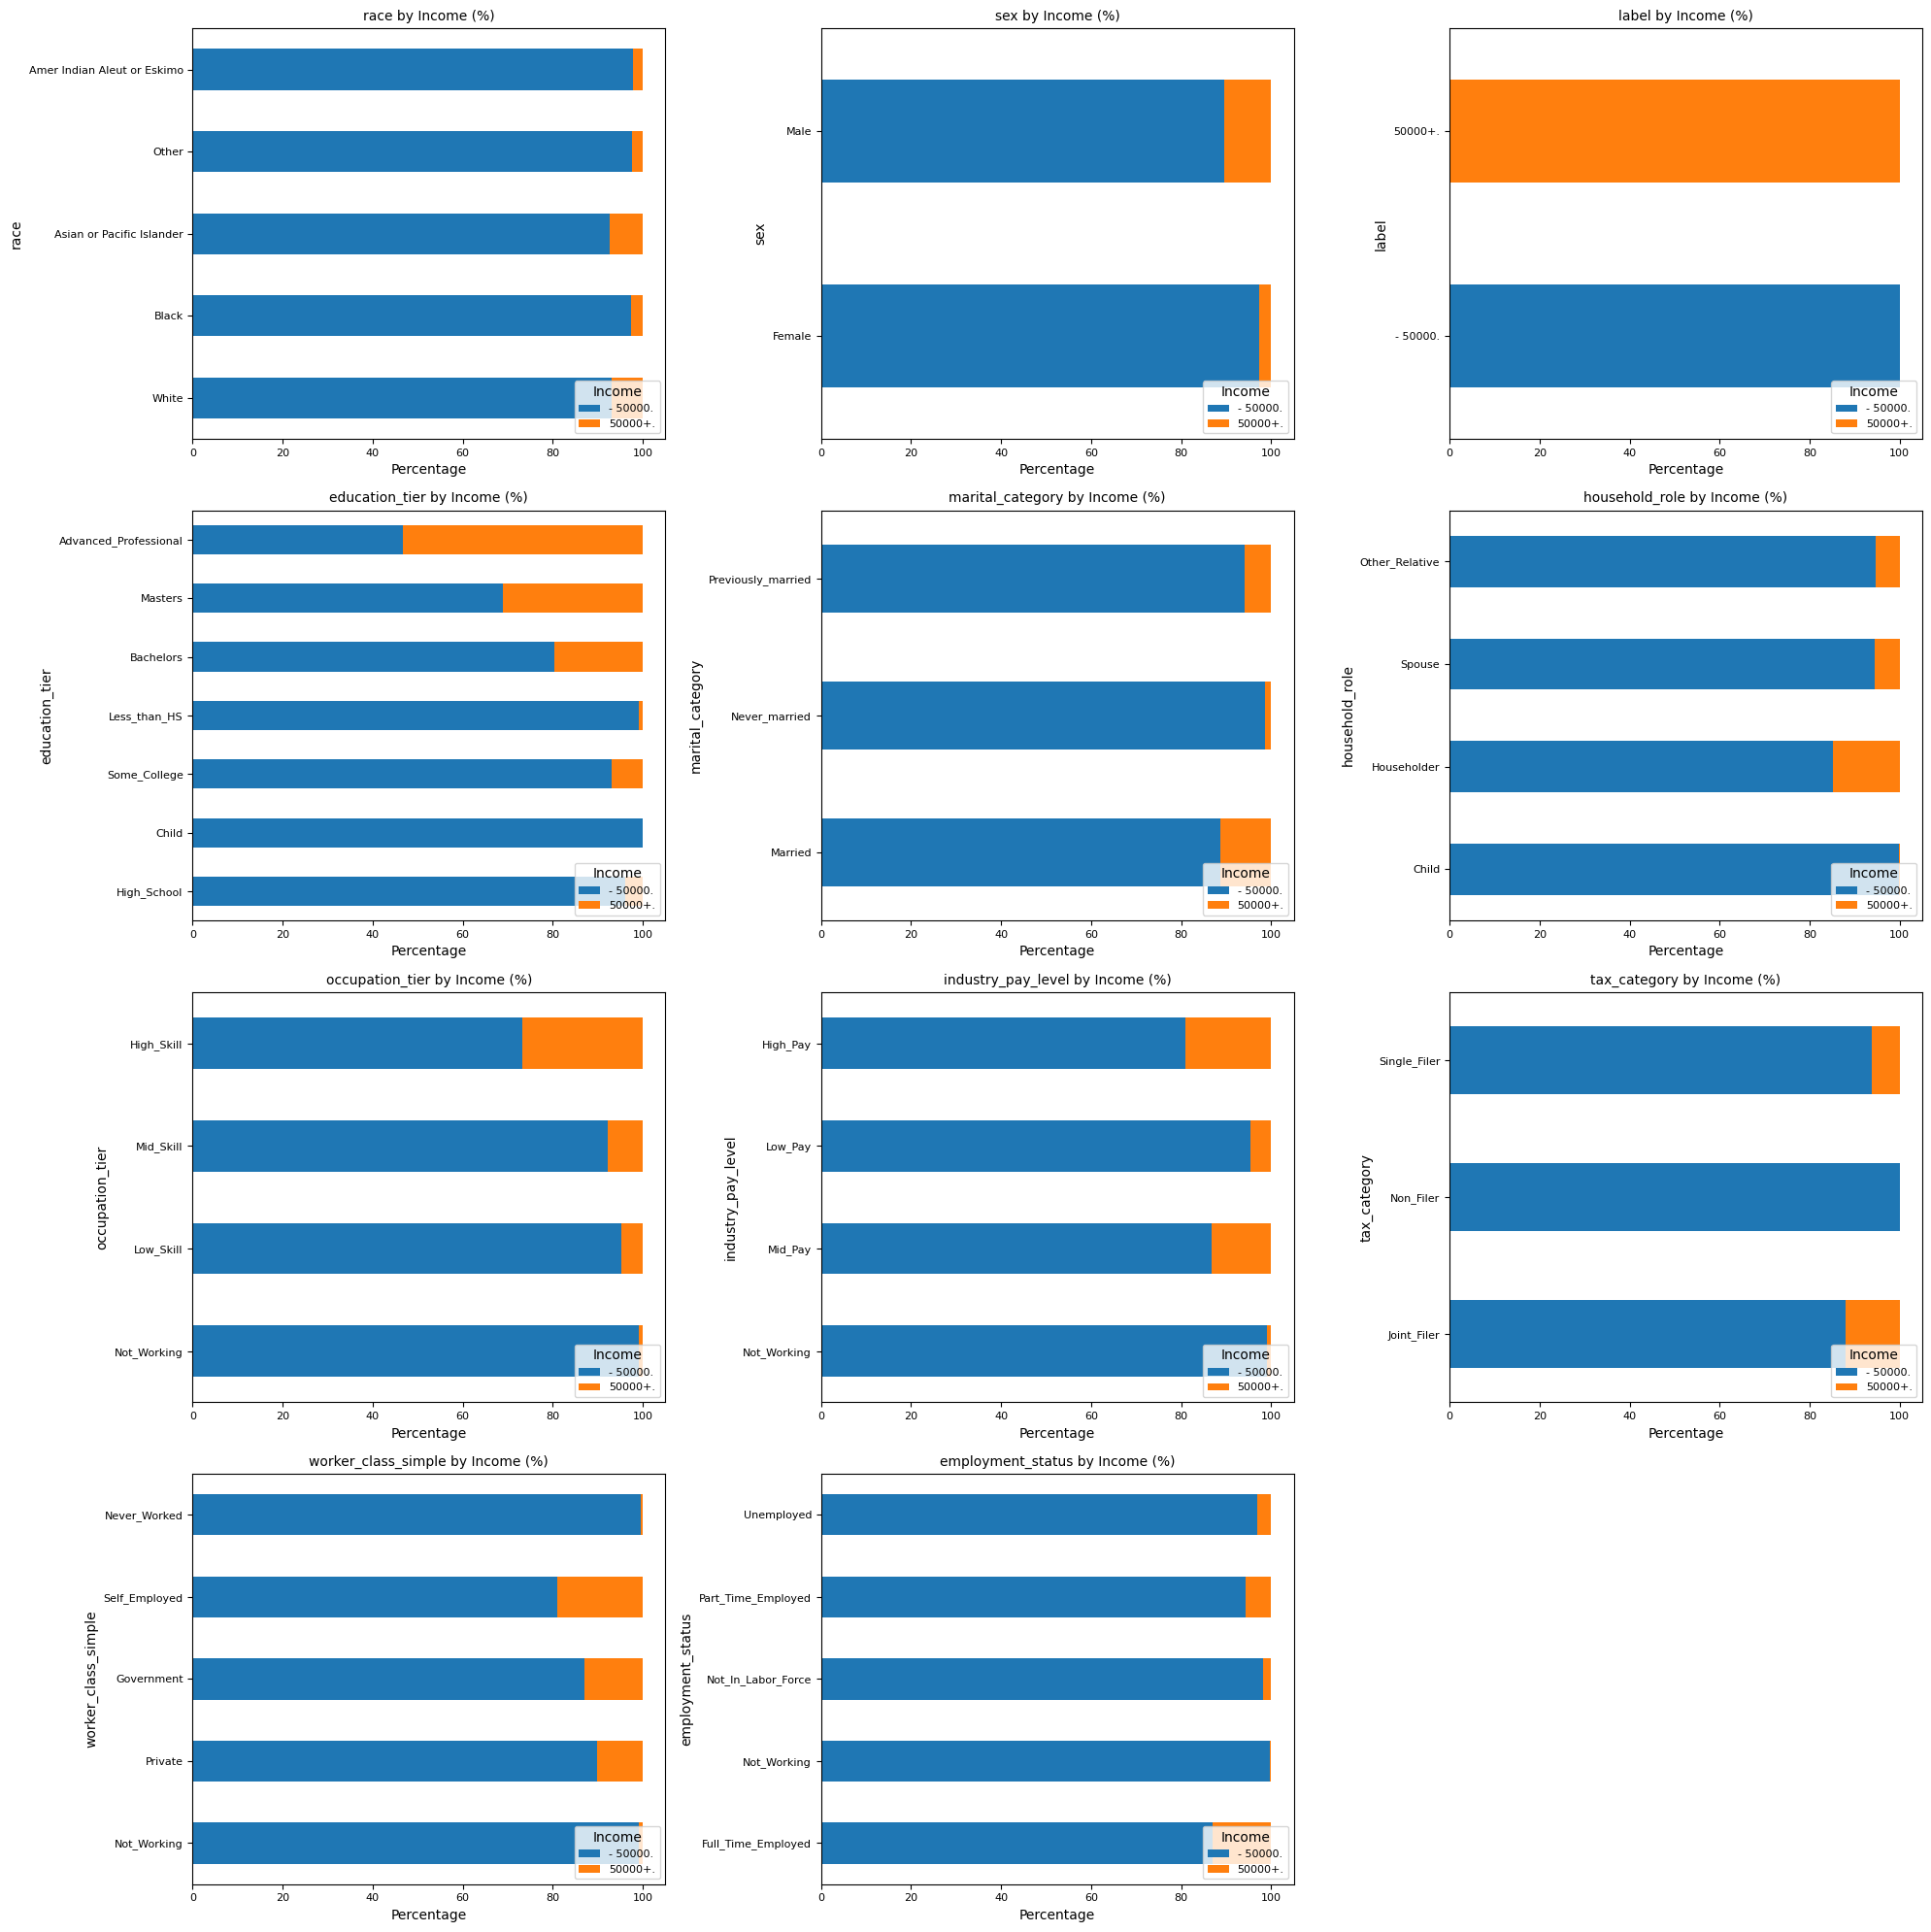

In [610]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

n_features = len(categorical_cols)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    ct = (
        pd.crosstab(df[col], df['label'], normalize='index') * 100
    )

    ct = ct.loc[df[col].value_counts().index[:15]]

    ct.plot(
        kind='barh',
        stacked=True,
        ax=axes[idx]
    )

    axes[idx].set_title(f'{col} by Income (%)', fontsize=10)
    axes[idx].set_xlabel('Percentage')
    axes[idx].tick_params(labelsize=8)
    axes[idx].legend(fontsize=8, title='Income', loc='lower right')

for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

Numerical features found: ['age', 'wage per hour', 'weight', 'num persons worked for employer', 'weeks worked in year', 'has_capital_gains', 'has_capital_losses', 'has_dividends', 'works_full_year']
Total: 9


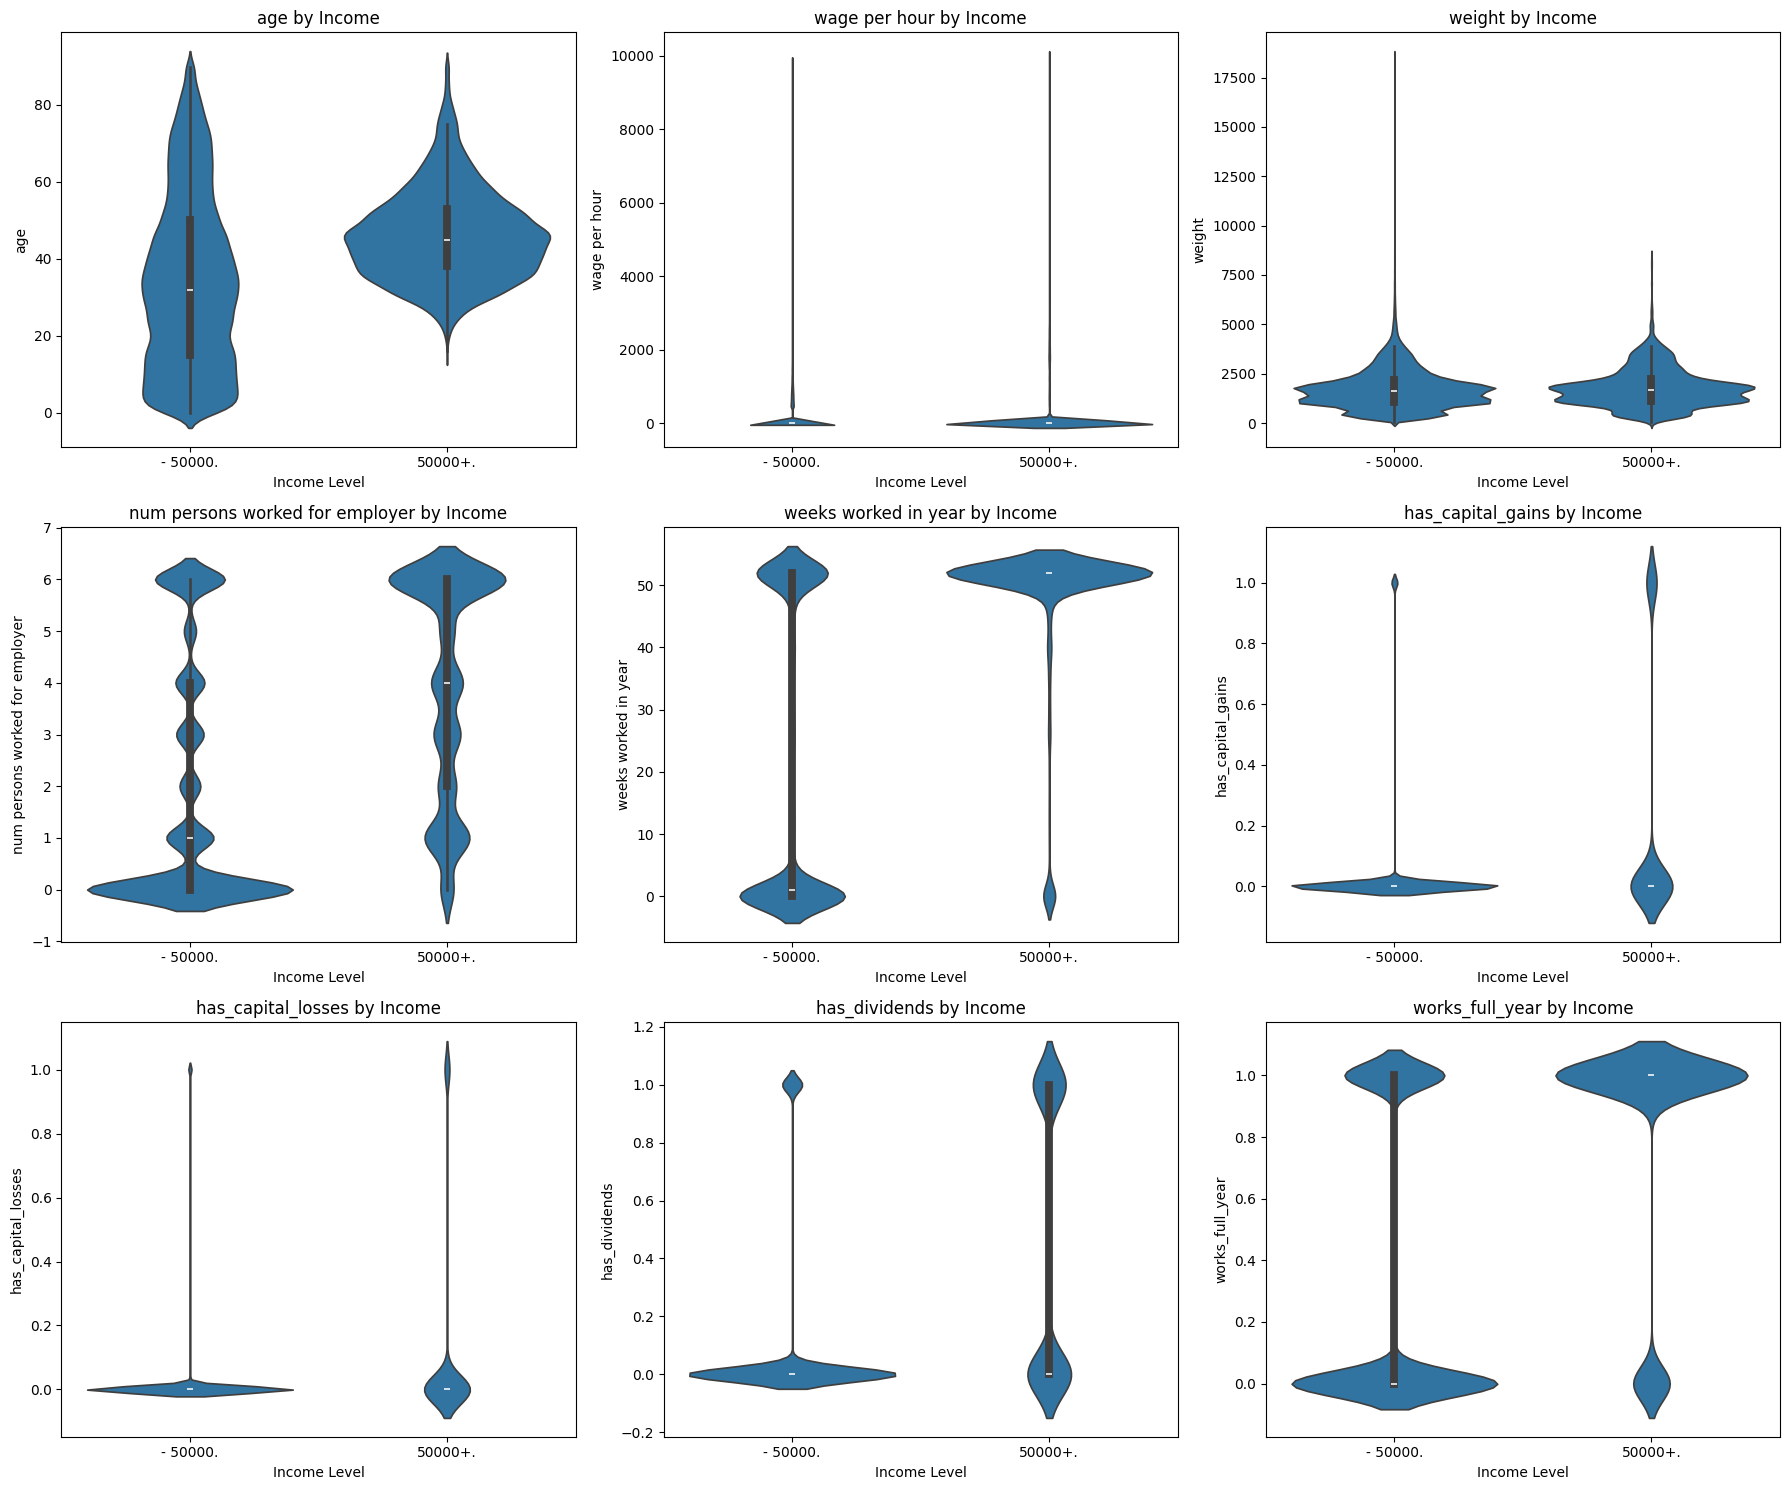

In [611]:
# Check with numerical columns 

actual_numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'label' in actual_numerical:
    actual_numerical.remove('label')

print(f"Numerical features found: {actual_numerical}")
print(f"Total: {len(actual_numerical)}")

n_features = len(actual_numerical)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.ravel()

for idx, col in enumerate(actual_numerical):
    sns.violinplot(x='label', y=col, data=df, ax=axes[idx])
    axes[idx].set_title(f'{col} by Income')
    axes[idx].set_xlabel('Income Level')

for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [612]:
# df.to_csv('census_processed.csv', index=False)

In [613]:
df.columns

Index(['age', 'wage per hour', 'race', 'sex', 'weight',
       'num persons worked for employer', 'weeks worked in year', 'label',
       'has_capital_gains', 'has_capital_losses', 'has_dividends',
       'works_full_year', 'education_tier', 'marital_category',
       'household_role', 'occupation_tier', 'industry_pay_level',
       'tax_category', 'worker_class_simple', 'employment_status'],
      dtype='object')

## Model Development

In [614]:
weight = df['weight'].copy()

X = df.drop('label', axis=1)
y = df['label']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test, weight_train, weight_test = train_test_split(
    X, y_encoded, weight,  
    test_size=0.2,          # 80/20 split 
    random_state=42,         
    stratify=y_encoded     
)

In [615]:
# Identify categorical columns
numerical_to_scale = ['age', 'weeks worked in year']
numerical_binary = ['has_capital_gains', 'has_capital_losses', 
                    'has_dividends', 'works_full_year']
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num_scale', StandardScaler(), numerical_to_scale),       
        ('num_binary', 'passthrough', numerical_binary),           
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), 
         categorical_features)                                       
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

### Logistic Regression

In [616]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_encoded, y_train, sample_weight=weight_train)

y_pred = lr.predict(X_test_encoded)
y_pred_proba = lr.predict_proba(X_test_encoded)[:, 1] 

In [617]:
print(classification_report(y_test, y_pred, target_names=['<50k', '>50k']))

              precision    recall  f1-score   support

        <50k       0.99      0.83      0.90     36647
        >50k       0.26      0.88      0.40      2476

    accuracy                           0.83     39123
   macro avg       0.63      0.86      0.65     39123
weighted avg       0.94      0.83      0.87     39123



Macro avg - real weakness of the model

Precision cares about False Positives - when the model predicted it to be >50 but in reality it is <50 - means (FP = 4755) 4755 number of times we target poor people instead of rich people. - this is expensive so I will optimize for precision 

Recall cares about False Negative - when the model preidcted it to be <50 but in reality it is >50 - means (TN = 409) 409 number of times we thought they are poor but they are rich (missed out on rich people)

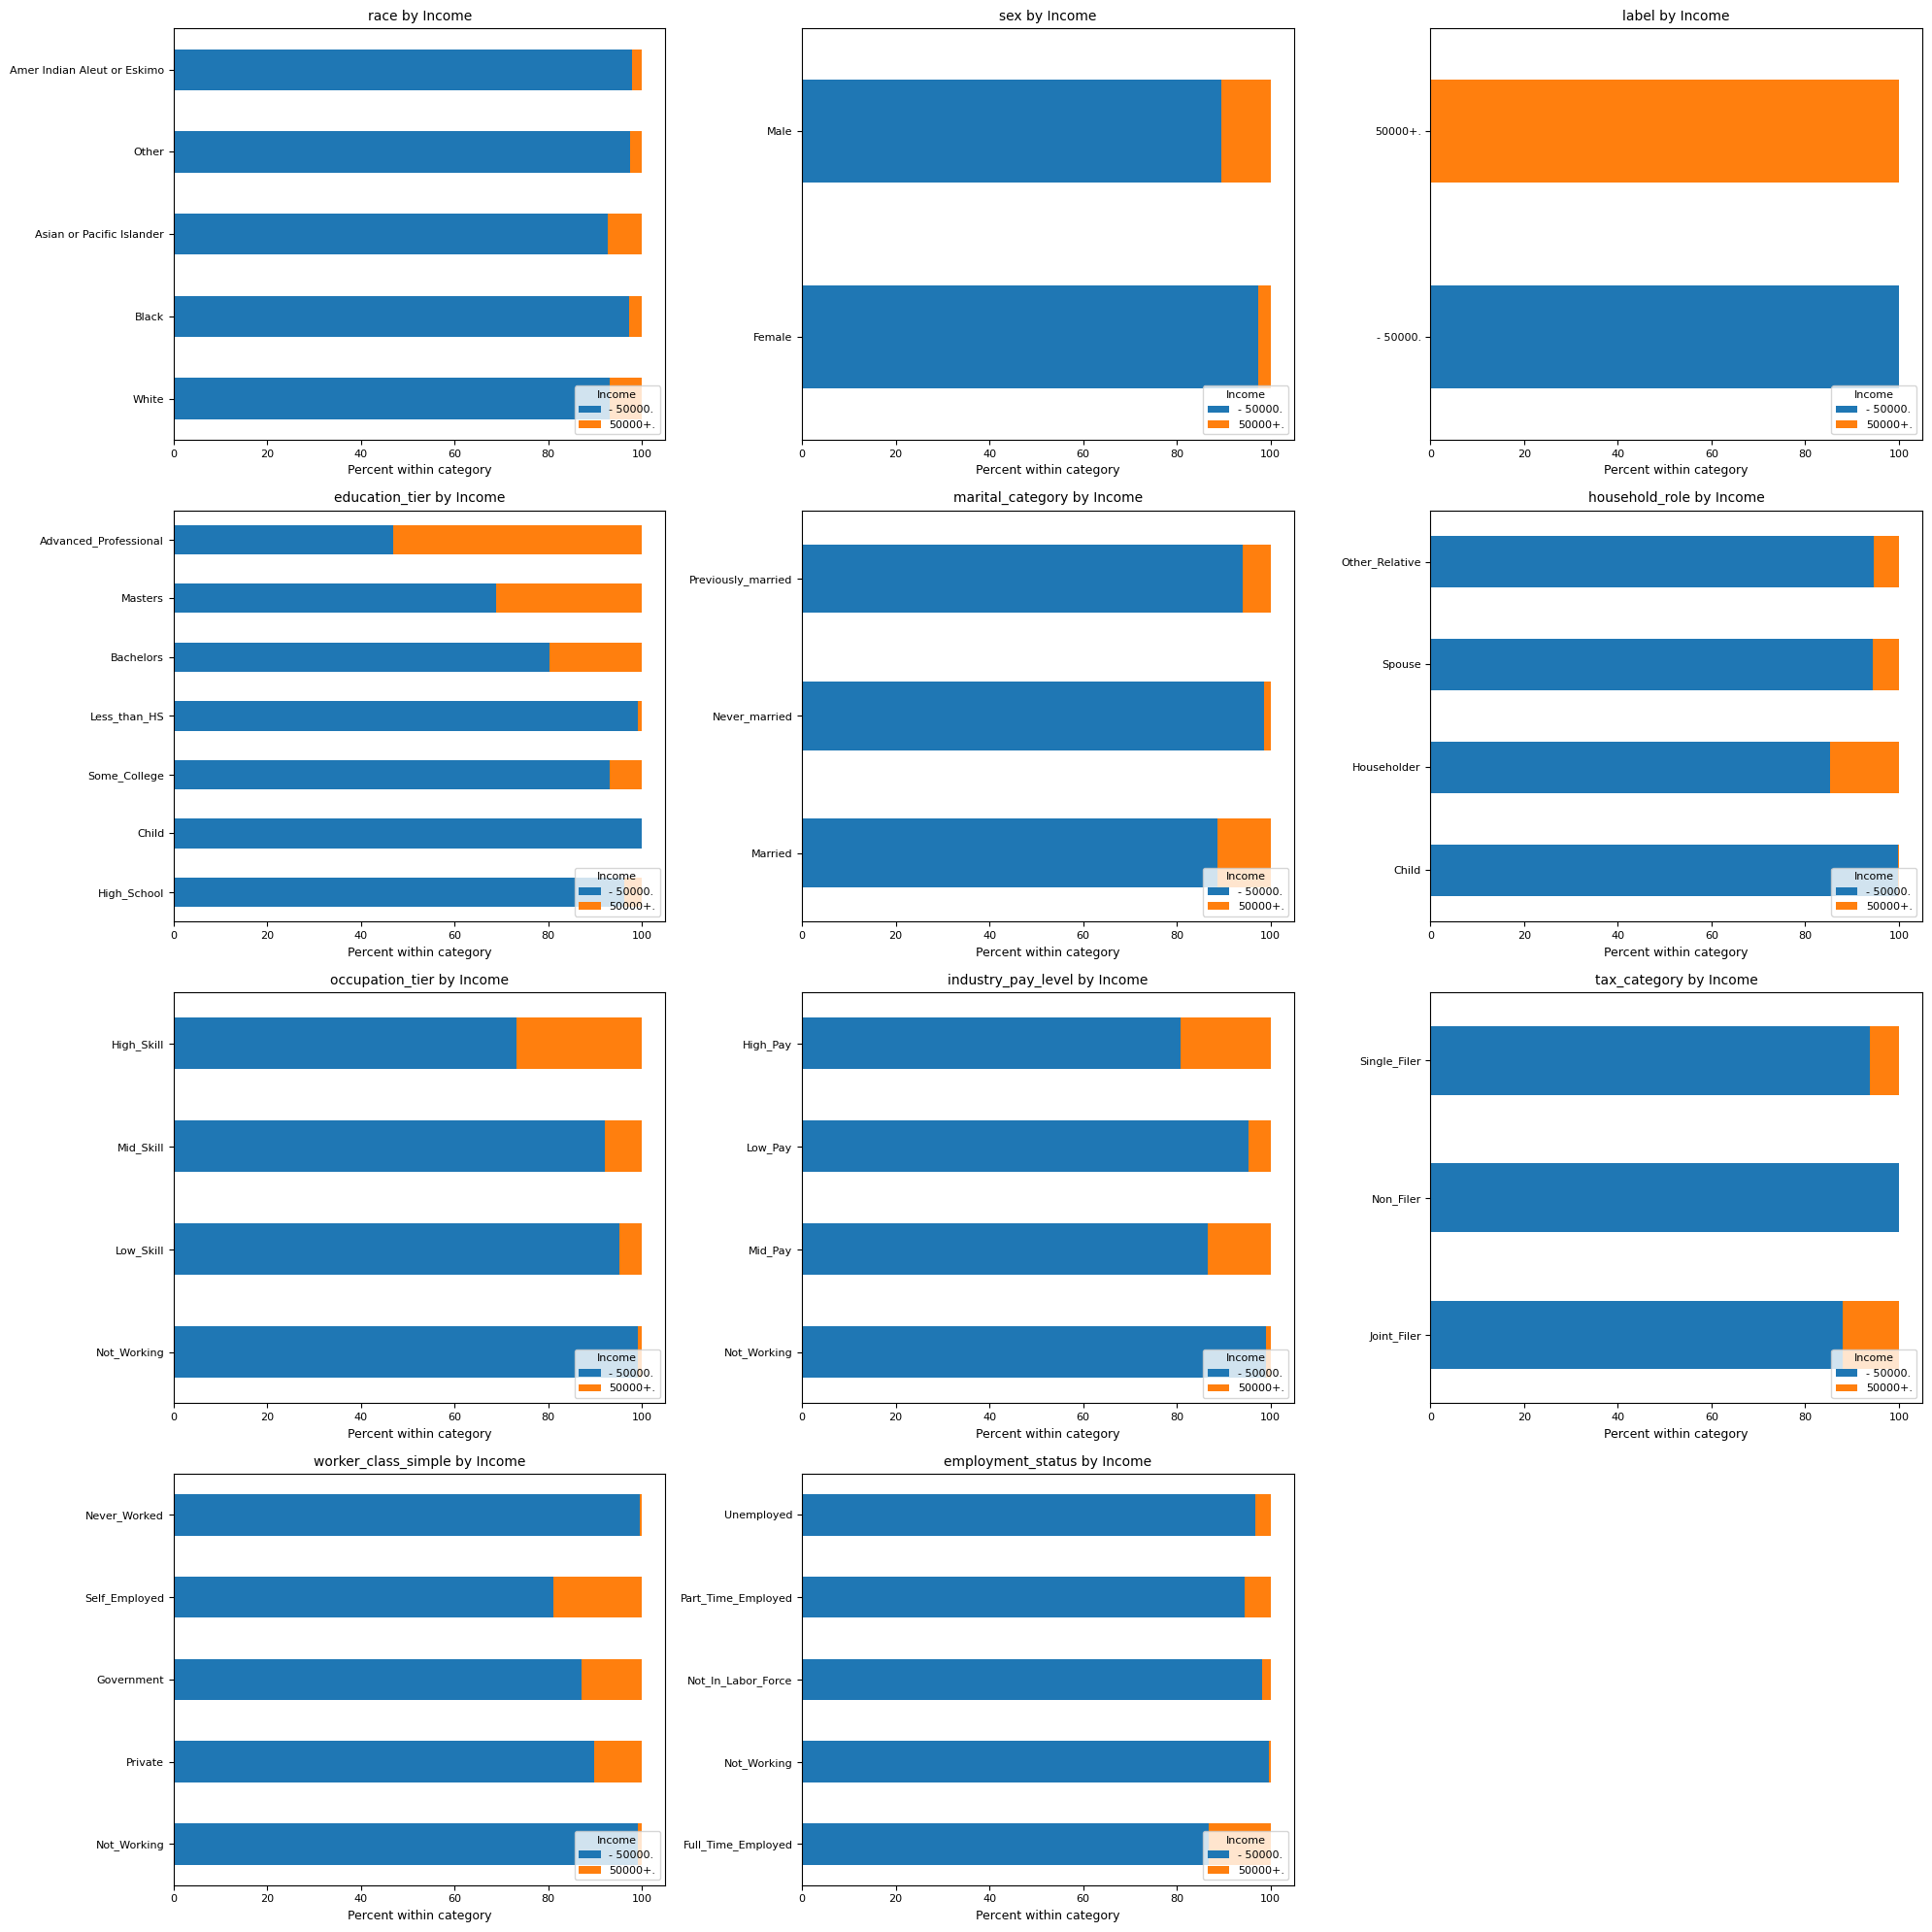

In [618]:
n_features = len(categorical_cols)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    top_cats = df[col].value_counts().head(15).index
    df_sub = df[df[col].isin(top_cats)].copy()
    ct = pd.crosstab(df_sub[col], df_sub['label'], normalize='index') * 100

    ct = ct.reindex(top_cats)

    ct.plot(kind='barh', stacked=True, ax=axes[idx])

    axes[idx].set_title(col + " by Income", fontsize=10)
    axes[idx].set_xlabel("Percent within category", fontsize=9)
    axes[idx].set_ylabel("")
    axes[idx].tick_params(labelsize=8)
    axes[idx].legend(title="Income", fontsize=8, title_fontsize=8, loc="lower right")

for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

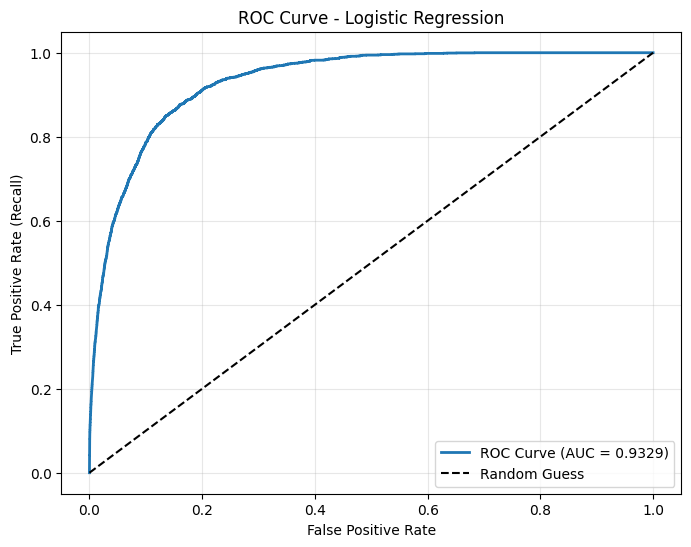

In [619]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [620]:
# i tried different thresholds but 0.80 is the best
thresholds_to_try = [0.60, 0.65, 0.70, 0.75, 0.80]

for thresh in thresholds_to_try:
    y_pred_temp = (y_pred_proba >= thresh).astype(int)
    
    precision = precision_score(y_test, y_pred_temp)
    recall = recall_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp)
    
    print(f"Threshold: {thresh:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")

Threshold: 0.60 | Precision: 0.314 | Recall: 0.830 | F1: 0.456
Threshold: 0.65 | Precision: 0.341 | Recall: 0.794 | F1: 0.477
Threshold: 0.70 | Precision: 0.368 | Recall: 0.742 | F1: 0.492
Threshold: 0.75 | Precision: 0.405 | Recall: 0.694 | F1: 0.511
Threshold: 0.80 | Precision: 0.451 | Recall: 0.636 | F1: 0.528


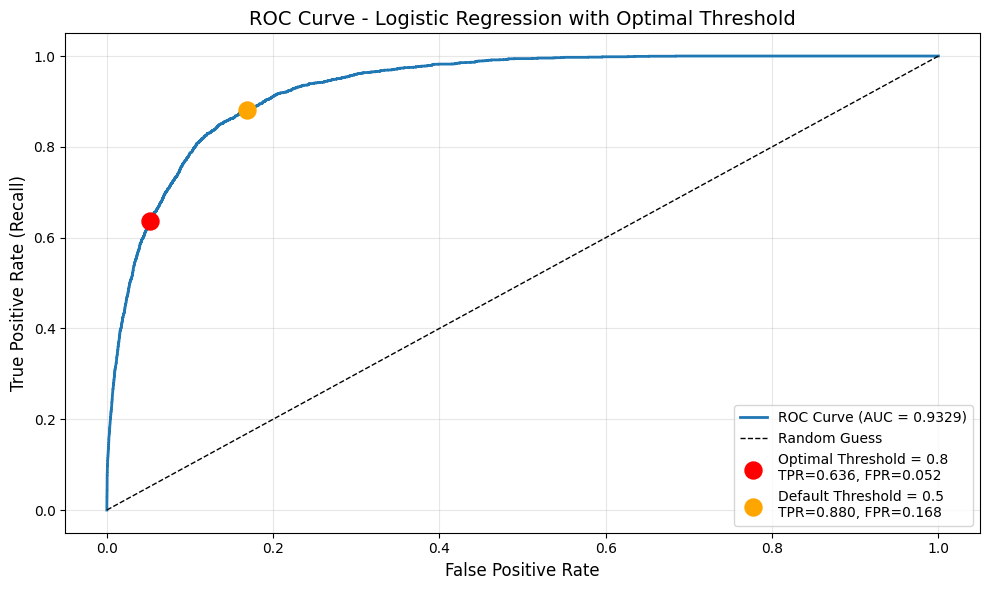

In [621]:
# plotting optimal and default thresholds

fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

optimal_threshold_lr = 0.80
idx = np.argmin(np.abs(roc_thresholds - optimal_threshold_lr))

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')


plt.scatter(fpr[idx], tpr[idx], color='red', s=150, zorder=5, 
           label=f'Optimal Threshold = {optimal_threshold_lr}\nTPR={tpr[idx]:.3f}, FPR={fpr[idx]:.3f}')


idx_default = np.argmin(np.abs(roc_thresholds - 0.5))
plt.scatter(fpr[idx_default], tpr[idx_default], color='orange', s=150, zorder=5, 
           label=f'Default Threshold = 0.5\nTPR={tpr[idx_default]:.3f}, FPR={fpr[idx_default]:.3f}')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - Logistic Regression with Optimal Threshold', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The ROC curve shows that while the model has strong discriminative power (AUC ≈ 0.91), adjusting the decision threshold from 0.5 to 0.8 significantly reduces false positives at the cost of recall, making it more suitable for marketing use cases where precision is more important.

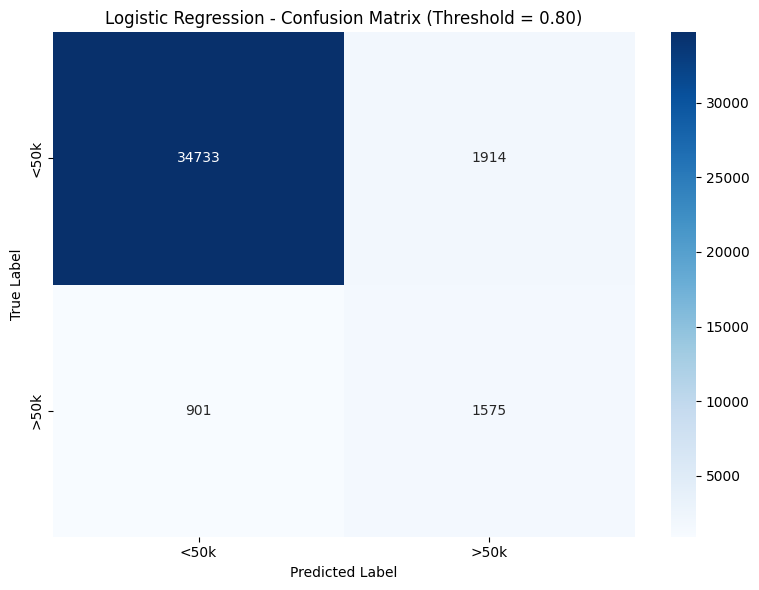

In [622]:
# Confusion Matrix at threshold 0.80
y_pred_lr_080 = (y_pred_proba >= 0.80).astype(int)
cm_lr = confusion_matrix(y_test, y_pred_lr_080)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['<50k', '>50k'], yticklabels=['<50k', '>50k'])
plt.title('Logistic Regression - Confusion Matrix (Threshold = 0.80)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### XGboost

In [623]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,  
    random_state=42,
    n_estimators=100
)

xgb.fit(X_train_encoded, y_train, sample_weight=weight_train)

y_pred_xgb = xgb.predict(X_test_encoded)
y_pred_proba_xgb = xgb.predict_proba(X_test_encoded)[:, 1]

In [624]:
print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb, target_names=['<50k', '>50k']))

roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb, sample_weight=weight_test)
print(f"\nROC-AUC: {roc_auc_xgb:.4f}")

XGBoost Results:
              precision    recall  f1-score   support

        <50k       0.99      0.85      0.92     36647
        >50k       0.28      0.84      0.42      2476

    accuracy                           0.85     39123
   macro avg       0.63      0.85      0.67     39123
weighted avg       0.94      0.85      0.88     39123


ROC-AUC: 0.9290


In [625]:
# i tried different thresholds but 0.85 is the best

thresholds_to_try = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9]

print("XGBoost Threshold Optimization:")
for thresh in thresholds_to_try:
    y_pred_temp = (y_pred_proba_xgb >= thresh).astype(int)
    
    from sklearn.metrics import precision_score, recall_score, f1_score
    precision = precision_score(y_test, y_pred_temp)
    recall = recall_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp)
    
    print(f"Threshold: {thresh:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")

XGBoost Threshold Optimization:
Threshold: 0.30 | Precision: 0.221 | Recall: 0.906 | F1: 0.355
Threshold: 0.40 | Precision: 0.250 | Recall: 0.880 | F1: 0.390
Threshold: 0.50 | Precision: 0.279 | Recall: 0.844 | F1: 0.419
Threshold: 0.60 | Precision: 0.319 | Recall: 0.804 | F1: 0.457
Threshold: 0.70 | Precision: 0.370 | Recall: 0.739 | F1: 0.493
Threshold: 0.80 | Precision: 0.452 | Recall: 0.643 | F1: 0.531
Threshold: 0.85 | Precision: 0.505 | Recall: 0.572 | F1: 0.537
Threshold: 0.90 | Precision: 0.578 | Recall: 0.474 | F1: 0.521


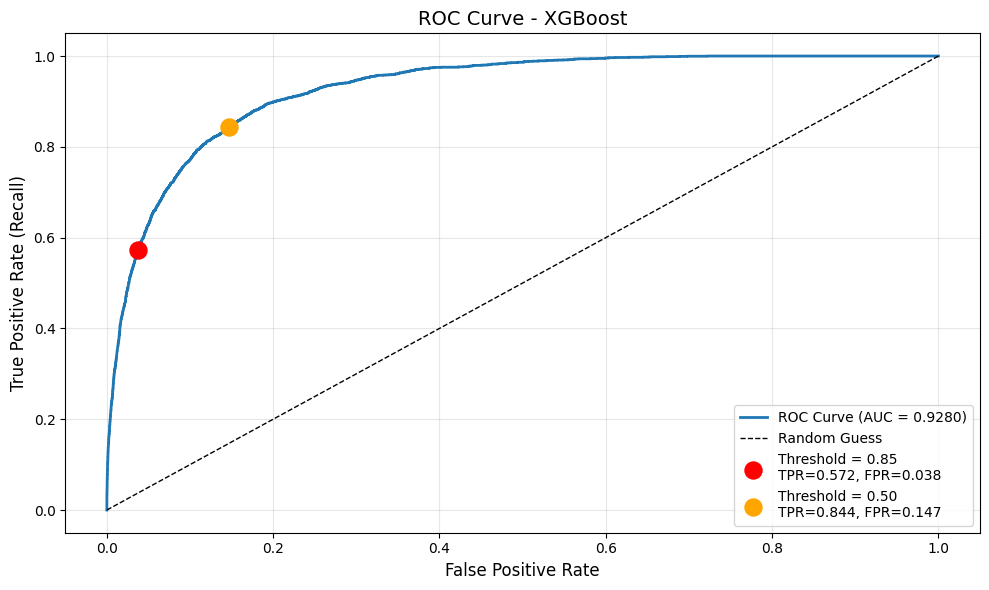

In [626]:
# XGBoost predicted probabilities (positive class)
y_pred_proba_xgb = xgb.predict_proba(X_test_encoded)[:, 1]

fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba_xgb)
roc_auc = roc_auc_score(y_test, y_pred_proba_xgb)

optimal_threshold_xgb = 0.85
idx_opt = np.argmin(np.abs(roc_thresholds - optimal_threshold_xgb))

idx_default = np.argmin(np.abs(roc_thresholds - 0.5))

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, linewidth=2, label='ROC Curve (AUC = {:.4f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')

plt.scatter(fpr[idx_opt], tpr[idx_opt], color='red', s=150, zorder=5,
            label='Threshold = {:.2f}\nTPR={:.3f}, FPR={:.3f}'.format(
                optimal_threshold_xgb, tpr[idx_opt], fpr[idx_opt]
            ))

plt.scatter(fpr[idx_default], tpr[idx_default], color='orange', s=150, zorder=5,
            label='Threshold = 0.50\nTPR={:.3f}, FPR={:.3f}'.format(
                tpr[idx_default], fpr[idx_default]
            ))

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - XGBoost', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The ROC curve shows strong class separation (AUC ≈ 0.93), delivering high recall with very low false positives at stricter thresholds, making it well-suited for precision-focused decisions.

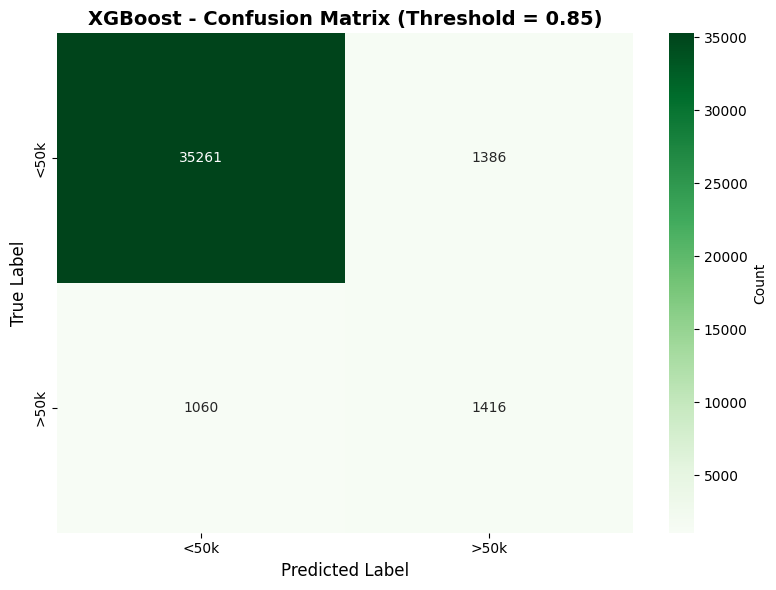

In [627]:
# XGBoost Confusion Matrix
y_pred_xgb_optimal = (y_pred_proba_xgb >= 0.85).astype(int)
cm_xgb = confusion_matrix(y_test, y_pred_xgb_optimal)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['<50k', '>50k'], 
            yticklabels=['<50k', '>50k'],
            cbar_kws={'label': 'Count'})
plt.title('XGBoost - Confusion Matrix (Threshold = 0.85)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

### Model Evaluation

In [628]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb, 
    X_train_encoded, 
    y_train, 
    cv=skf, 
    scoring='roc_auc',
    params={'sample_weight': weight_train}
)

print(f"CV ROC-AUC: {cv_scores.mean():.4f} ")

CV ROC-AUC: 0.9281 


### ROC Curves Comparison

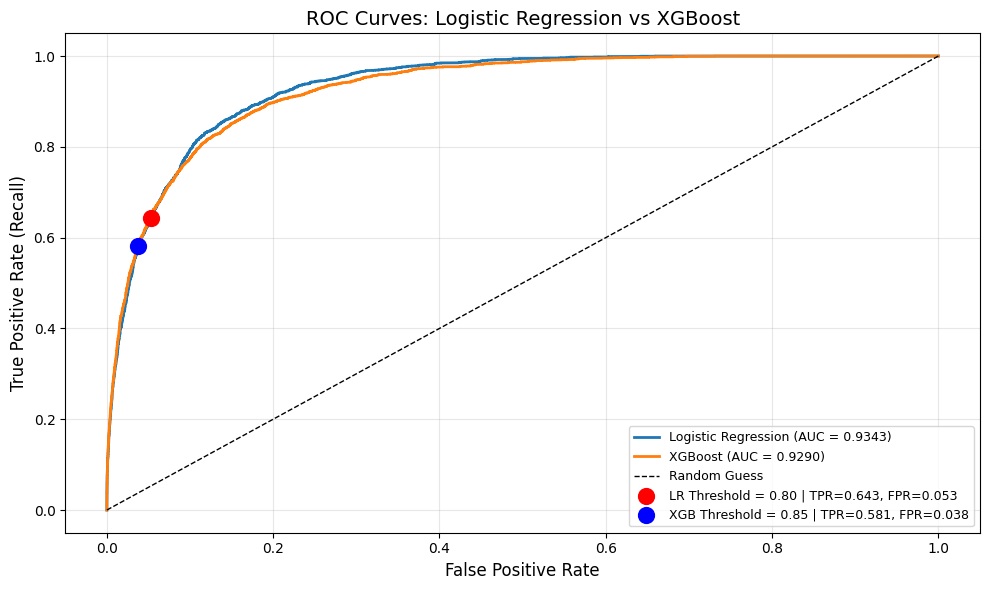

In [629]:
optimal_threshold_lr  = 0.80
optimal_threshold_xgb = 0.85

sw = weight_test if 'weight_test' in globals() else None

fpr_lr, tpr_lr, thr_lr = roc_curve(y_test, y_pred_proba, sample_weight=sw)
auc_lr = roc_auc_score(y_test, y_pred_proba, sample_weight=sw)

fpr_xgb, tpr_xgb, thr_xgb = roc_curve(y_test, y_pred_proba_xgb, sample_weight=sw)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb, sample_weight=sw)

idx_lr_opt  = np.argmin(np.abs(thr_lr  - optimal_threshold_lr))
idx_xgb_opt = np.argmin(np.abs(thr_xgb - optimal_threshold_xgb))

idx_lr_05  = np.argmin(np.abs(thr_lr  - 0.5))
idx_xgb_05 = np.argmin(np.abs(thr_xgb - 0.5))


plt.figure(figsize=(10, 6))

plt.plot(fpr_lr,  tpr_lr,  linewidth=2, label='Logistic Regression (AUC = %.4f)' % auc_lr)
plt.plot(fpr_xgb, tpr_xgb, linewidth=2, label='XGBoost (AUC = %.4f)' % auc_xgb)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')

plt.scatter(
    fpr_lr[idx_lr_opt], tpr_lr[idx_lr_opt],
    color='red', s=130, zorder=5,
    label='LR Threshold = %.2f | TPR=%.3f, FPR=%.3f' % (optimal_threshold_lr, tpr_lr[idx_lr_opt], fpr_lr[idx_lr_opt])
)

plt.scatter(
    fpr_xgb[idx_xgb_opt], tpr_xgb[idx_xgb_opt],
    color='blue', s=130, zorder=5,
    label='XGB Threshold = %.2f | TPR=%.3f, FPR=%.3f' % (optimal_threshold_xgb, tpr_xgb[idx_xgb_opt], fpr_xgb[idx_xgb_opt])
)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves: Logistic Regression vs XGBoost', fontsize=14)
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

At a precision-focused operating threshold of 0.85, XGBoost outperforms Logistic Regression by identifying more high-income individuals.

The lower false positive rate with XGBoost means less wasted marketing spend on low-income individuals incorrectly predicted as high-income.

### Model Comparison

In [630]:
# Logistic Regression
lr_pred_080 = (y_pred_proba > 0.80).astype(int)
lr_precision = precision_score(y_test, lr_pred_080, sample_weight=weight_test)
lr_recall = recall_score(y_test, lr_pred_080, sample_weight=weight_test)
lr_f1 = f1_score(y_test, lr_pred_080, sample_weight=weight_test)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba, sample_weight=weight_test)

# XGBoost
xgb_pred_080 = (y_pred_proba_xgb > 0.85).astype(int)
xgb_precision = precision_score(y_test, xgb_pred_080, sample_weight=weight_test)
xgb_recall = recall_score(y_test, xgb_pred_080, sample_weight=weight_test)
xgb_f1 = f1_score(y_test, xgb_pred_080, sample_weight=weight_test)
xgb_roc_auc = roc_auc_score(y_test, y_pred_proba_xgb, sample_weight=weight_test)

# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': [
        round(lr_roc_auc, 4),
        round(lr_precision, 3),
        round(lr_recall, 3),
        round(lr_f1, 3)
    ],
    'XGBoost': [
        round(xgb_roc_auc, 4),
        round(xgb_precision, 3),
        round(xgb_recall, 3),
        round(xgb_f1, 3)
    ]
})

print("Model Comparison at their optimal threshold:")
print("-"*70)
print(comparison_df.to_string(index=False))

Model Comparison at their optimal threshold:
----------------------------------------------------------------------
   Metric  Logistic Regression  XGBoost
  ROC-AUC               0.9343    0.929
Precision               0.4650    0.522
   Recall               0.6430    0.580
 F1 Score               0.5400    0.549


At a high operating threshold (0.80), XGBoost outperforms Logistic Regression for marketing use cases due to higher precision and F1 score, indicating more efficient targeting with reduced wasted outreach, while maintaining comparable ranking performance as measured by ROC–AUC

# SHAP Analysis

In [631]:
feature_names_encoded = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_encoded)

### Summary Plot

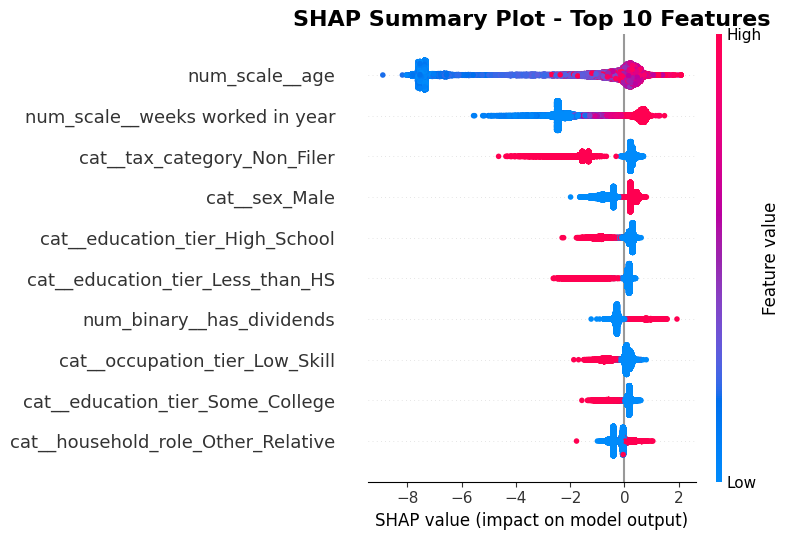

In [632]:
plt.figure(figsize=(12, 10))

shap.summary_plot(
    shap_values,
    X_test_encoded,
    feature_names=feature_names_encoded,
    max_display=10,  
    show=False
)

plt.title("SHAP Summary Plot - Top 10 Features", fontsize=16, fontweight='bold')
plt.xlabel("SHAP value (impact on model output)", fontsize=12)
plt.tight_layout()
plt.show()

The SHAP analysis shows that age, employment stability, education level, and capital income are the strongest drivers of high-income predictions. Higher age, more weeks worked, and the presence of dividends push predictions toward the >50k class, while non-filing tax status, low education, and low-skill occupations strongly push predictions toward <50k. These patterns align with economic intuition, indicating the model has learned meaningful, interpretable relationships rather than spurious correlations.

### Dependence plots


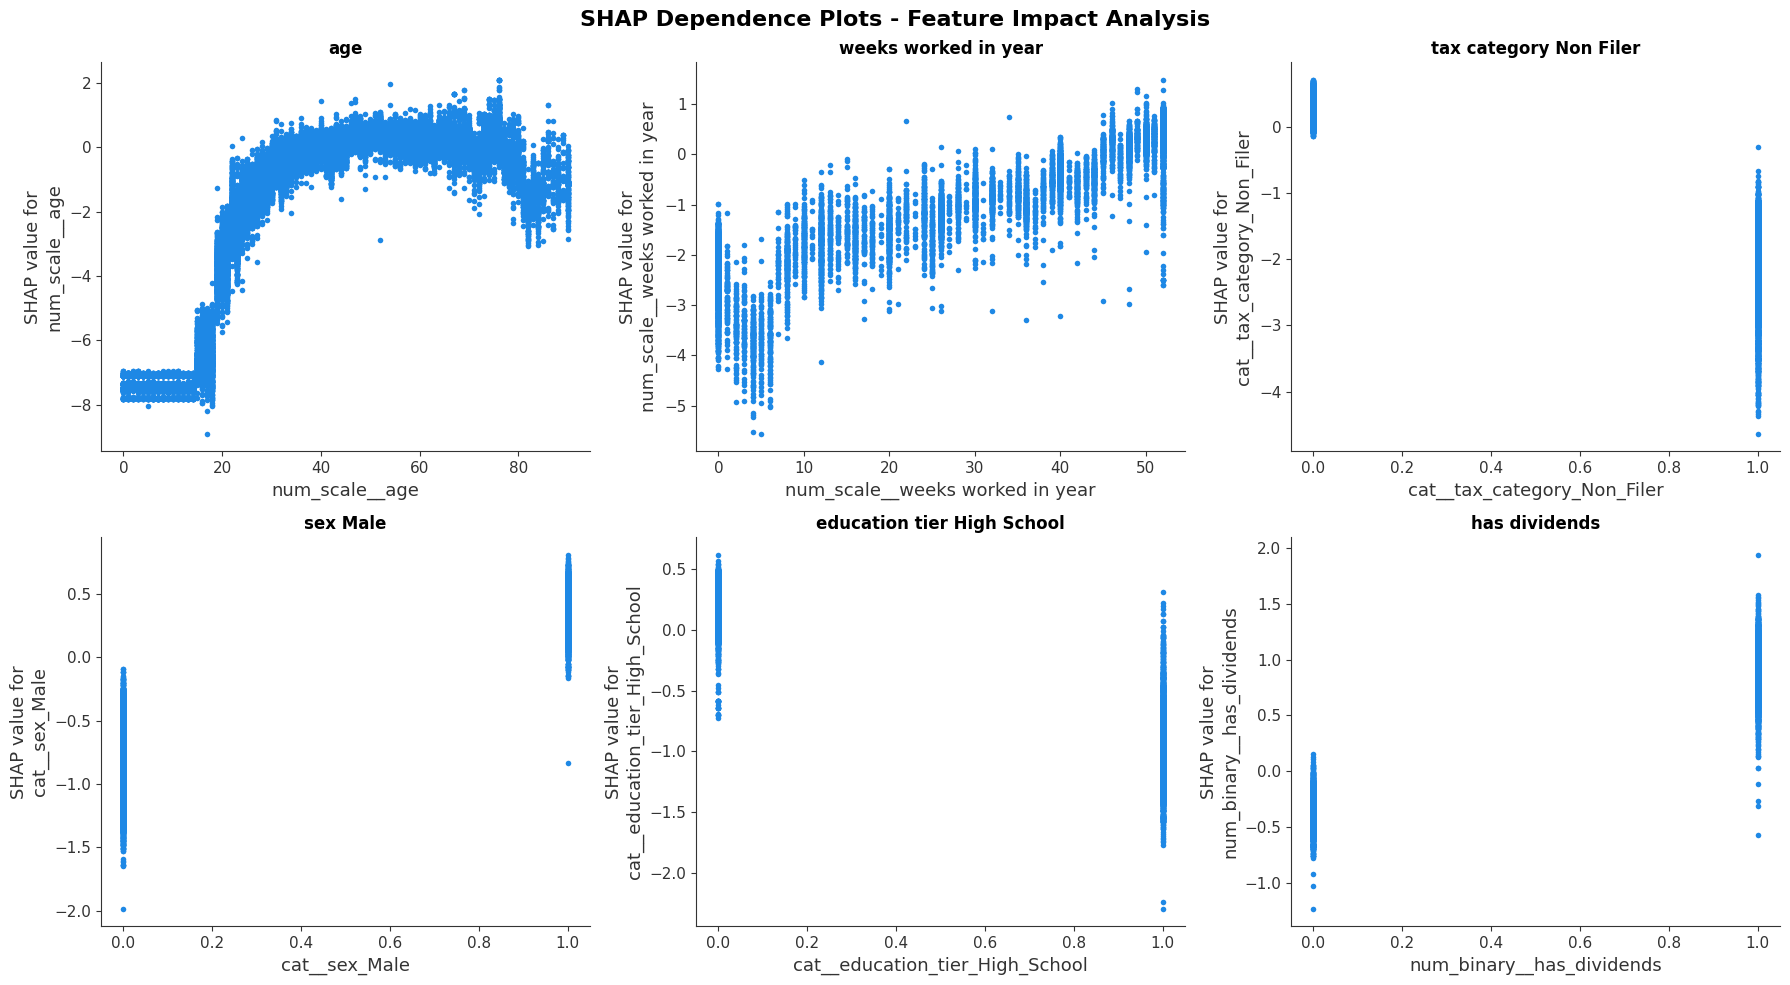

In [633]:
X_test_for_shap = pd.DataFrame(X_test_encoded, columns=feature_names_encoded)
X_test_for_shap['num_scale__age'] = X_test['age'].values
X_test_for_shap['num_scale__weeks worked in year'] = X_test['weeks worked in year'].values

# Features to plot 
features_to_plot = [
    "num_scale__age",
    "num_scale__weeks worked in year",
    "cat__tax_category_Non_Filer",
    "cat__sex_Male",
    "cat__education_tier_High_School",
    "num_binary__has_dividends",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    shap.dependence_plot(
        feature,
        shap_values,
        X_test_for_shap,
        interaction_index=None,
        ax=axes[idx],
        show=False
    )
    
    title = feature.replace('num_scale__', '').replace('cat__', '').replace('num_binary__', '').replace('_', ' ')
    axes[idx].set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('SHAP Dependence Plots - Feature Impact Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Age dominates predictions with a threshold effect (under 25: SHAP ≈ -8; ages 30-60: progressively positive), followed by full-year employment showing consistent positive impact. Gender reflects wage gaps, financial indicators like dividends show age-dependent effects, and low-skill occupations consistently predict lower income. Optimal targets: ages 35-60, full-year employed, skilled occupations, with financial indicators.